# Who builds the honest chatbot? A subsidy auction with a compliance audit
COMSCI/ECON 206 Computational Microeconomics · Autumn 2026 Session 1 · PS2 computational artifact

**Question.** A government funds one company, from a fixed grant pool, to build a non-sycophantic chatbot. How do the payment rule (second-price vs. first-price reverse auction) and the audit strength change government spending, spending risk, allocation efficiency, and whether an honest chatbot is actually delivered?

**Run.** *Runtime → Run all.* Python standard library plus matplotlib (preinstalled in Colab). Deterministic: seed 206 for all simulations. All inputs are synthetic; no human data. The first code cell writes `chatbot_auction.py`, identical to the GitHub file, so the notebook needs no other file.

| Symbol | Meaning | Baseline |
|---|---|---|
| $n$ | companies per auction | 4 |
| $c_i$ | private cost of building the honest chatbot, i.i.d. $U[0,100]$ | — |
| $B$ | grant cap = fixed subsidy pool (reserve price) | 80 |
| $E$ | extra engagement revenue from a sycophantic chatbot | 30 |
| $k$ | extra tuning cost of making it sycophantic | 10 |
| $p$ | probability the regulator audits the winner | 0.5 (swept 0–1) |
| $F$ | fine if the audit finds sycophancy | 50 |

In [1]:
%%writefile chatbot_auction.py
"""Who builds the honest chatbot? A reverse subsidy auction with a post-award compliance audit.

COMSCI/ECON 206 PS2 computational artifact. Python standard library only (matplotlib is used
only by the optional plotting helpers). The rules, benchmarks, and seeded random generator are
a line-by-line port of the Hugging Face game's game_logic.js, so a session code produces the
same costs, audits, and outcomes in both artifacts.
"""
from __future__ import annotations

import csv
import json
import math
import statistics
from dataclasses import asdict, dataclass, replace

MASK = 0xFFFFFFFF
RULES = ("second", "first")
RULE_NAMES = {"second": "Second-price", "first": "First-price"}
RIVAL_NAMES = ("Rival A", "Rival B", "Rival C")


@dataclass(frozen=True)
class Config:
    n: int = 4                     # companies per auction
    cost_max: float = 100.0        # private cost of the honest chatbot ~ Uniform(0, cost_max)
    cap: float = 80.0              # fixed subsidy pool: maximum grant (reserve price)
    engagement_gain: float = 30.0  # E: extra engagement revenue from a sycophantic chatbot
    extra_tuning_cost: float = 10.0  # k: extra cost of tuning the chatbot to be sycophantic
    audit_prob: float = 0.5        # p: probability the regulator audits the winner
    fine: float = 50.0             # F: fine when the audit finds sycophancy
    rounds_per_rule: int = 3       # game rounds under each rule

    def __post_init__(self):
        values = asdict(self)
        if any(not math.isfinite(v) for v in values.values()):
            raise ValueError("Parameters must be finite.")
        if self.n < 2 or self.rounds_per_rule < 1:
            raise ValueError("Need at least 2 companies and 1 round per rule.")
        if not 0 < self.cap <= self.cost_max:
            raise ValueError("Cap must lie in (0, cost_max].")
        if not 0 <= self.audit_prob <= 1:
            raise ValueError("Audit probability must lie in [0, 1].")
        if min(self.engagement_gain, self.extra_tuning_cost, self.fine) < 0:
            raise ValueError("Gain, tuning cost, and fine must be nonnegative.")
        if cheating_rent(self) > self.cost_max - self.cap:
            raise ValueError("Cheating rent must not exceed cost_max - cap for the first-price formula.")


def round1(x: float) -> float:
    """JavaScript Math.round(x * 10) / 10 (round half up), for exact parity with the game."""
    return math.floor(x * 10 + 0.5) / 10


def seed_from_code(code) -> int:
    """FNV-1a over UTF-16 code units, matching the game's seedFromCode."""
    data = str(code).encode("utf-16-le")
    h = 0x811C9DC5
    for i in range(0, len(data), 2):
        h ^= data[i] | (data[i + 1] << 8)
        h = (h * 0x01000193) & MASK
    return h


def mulberry32(seed: int):
    """32-bit mulberry32 generator returning floats in [0, 1), matching the game."""
    a = seed & MASK

    def imul(x, y):
        return (x * y) & MASK

    def rng() -> float:
        nonlocal a
        a = (a + 0x6D2B79F5) & MASK
        t = imul(a ^ (a >> 15), a | 1)
        t ^= (t + imul(t ^ (t >> 7), t | 61)) & MASK
        return ((t ^ (t >> 14)) & MASK) / 4294967296

    return rng


def cheat_gain(cfg: Config) -> float:
    """Net gain from shipping the sycophantic chatbot before any fine: E - k."""
    return cfg.engagement_gain - cfg.extra_tuning_cost


def expected_cheat_value(cfg: Config) -> float:
    """Expected value of cheating relative to complying: (E - k) - pF."""
    return cheat_gain(cfg) - cfg.audit_prob * cfg.fine


def audit_threshold(cfg: Config) -> float:
    """Audit probability at which a risk-neutral winner is indifferent: p* = (E - k) / F."""
    return cheat_gain(cfg) / cfg.fine if cfg.fine > 0 else math.inf


def rational_cheats(cfg: Config) -> bool:
    return expected_cheat_value(cfg) > 1e-9


def cheating_rent(cfg: Config) -> float:
    """Expected cheating rent a rational bidder passes into its bid; zero when audits deter cheating."""
    return max(0.0, expected_cheat_value(cfg))


BASELINE = Config()


def benchmark_bid_exact(cost: float, rule: str, cfg: Config) -> float:
    """Risk-neutral IPV benchmark bid for a company with the given honest-build cost.

    Second price: bid the effective cost e = cost - rent, floored at 0 (weakly dominant).
    First price: symmetric BNE of a reverse auction with reserve `cap` and e ~ U[-rent, M],
        b(e) = e + [(M - e)^n - (M - cap)^n] / [n (M - e)^(n-1)],  M = cost_max - rent.
    """
    rent = cheating_rent(cfg)
    e = cost - rent
    if rule == "second":
        return max(0.0, e)
    if rule != "first":
        raise ValueError(f"Unknown rule: {rule}")
    if e >= cfg.cap:
        return e
    m, n = cfg.cost_max - rent, cfg.n
    return e + ((m - e) ** n - (m - cfg.cap) ** n) / (n * (m - e) ** (n - 1))


def benchmark_bid(cost: float, rule: str, cfg: Config = BASELINE) -> float:
    """Benchmark bid rounded to 0.1, as displayed and used by the game's computer rivals."""
    return round1(benchmark_bid_exact(cost, rule, cfg))


def valid_bid(bid) -> bool:
    return isinstance(bid, (int, float)) and not isinstance(bid, bool) and math.isfinite(bid) and 0 <= bid <= 100


def run_auction(bids, rule: str, cap: float, rounding: bool = True):
    """Lowest bid <= cap wins; ties go to the lower index (the player is index 0).

    Second price pays min(second-lowest bid, cap); first price pays the winner's bid.
    Returns (winner, payment) with winner = -1 when no bid is at or below the cap.
    """
    if len(bids) < 2 or not all(valid_bid(b) for b in bids):
        raise ValueError("Bids must be at least two numbers between 0 and 100.")
    order = sorted(range(len(bids)), key=lambda i: (bids[i], i))
    winner = order[0]
    if bids[winner] > cap:
        return -1, 0.0
    if rule == "second":
        payment = min(bids[order[1]], cap)
    elif rule == "first":
        payment = bids[winner]
    else:
        raise ValueError(f"Unknown rule: {rule}")
    return winner, round1(payment) if rounding else payment


def is_efficient(costs, winner: int, cap: float) -> bool:
    """True when the lowest-cost company with cost <= cap wins, or nobody wins because all costs exceed cap."""
    eligible = [i for i, c in enumerate(costs) if c <= cap]
    if not eligible:
        return winner == -1
    best = min(eligible, key=lambda i: (costs[i], i))
    return winner != -1 and costs[winner] == costs[best]


def round_profit(won: bool, payment: float, cost: float, cheat: bool, caught: bool,
                 cfg: Config = BASELINE, rounding: bool = True) -> float:
    if not won:
        return 0.0
    profit = payment - cost
    if cheat:
        profit += cheat_gain(cfg) - (cfg.fine if caught else 0.0)
    return round1(profit) if rounding else profit


def make_schedule(code, cfg: Config = BASELINE) -> dict:
    """Deterministic game schedule: costs, audits, and rule order for a session code."""
    seed = seed_from_code(code)
    rng = mulberry32(seed)
    rule_order = ["second", "first"] if seed % 2 == 0 else ["first", "second"]
    rounds = []
    for i in range(2 * cfg.rounds_per_rule):
        player_cost = round1(rng() * cfg.cost_max)
        rival_costs = [round1(rng() * cfg.cost_max) for _ in range(cfg.n - 1)]
        audited = rng() < cfg.audit_prob
        rounds.append({
            "round": i + 1,
            "rule": rule_order[i // cfg.rounds_per_rule],
            "playerCost": player_cost,
            "rivalCosts": rival_costs,
            "audited": audited,
        })
    return {"code": str(code), "seed": seed, "ruleOrder": rule_order, "rounds": rounds}


def resolve_round(r: dict, player_bid: float, player_cheats: bool, cfg: Config = BASELINE) -> dict:
    """One game round given the player's bid and comply/cheat choice (same fields as the game)."""
    rival_bids = [benchmark_bid(c, r["rule"], cfg) for c in r["rivalCosts"]]
    bids = [player_bid] + rival_bids
    costs = [r["playerCost"]] + r["rivalCosts"]
    winner, payment = run_auction(bids, r["rule"], cfg.cap)
    cheated = None
    if winner == 0:
        cheated = bool(player_cheats)
    elif winner > 0:
        cheated = rational_cheats(cfg)
    caught = cheated is True and r["audited"]
    bench = benchmark_bid(r["playerCost"], r["rule"], cfg)
    return {
        "round": r["round"],
        "rule": r["rule"],
        "playerCost": r["playerCost"],
        "playerBid": player_bid,
        "benchmarkBid": bench,
        "bidGap": round1(player_bid - bench),
        "rivalCosts": list(r["rivalCosts"]),
        "rivalBids": rival_bids,
        "winner": winner,
        "winnerName": "Nobody" if winner == -1 else "You" if winner == 0 else RIVAL_NAMES[winner - 1],
        "payment": payment,
        "efficient": is_efficient(costs, winner, cfg.cap),
        "cheated": cheated,
        "audited": None if winner == -1 else r["audited"],
        "caught": caught,
        "honestDelivered": None if winner == -1 else cheated is False,
        "playerProfit": round_profit(winner == 0, payment, r["playerCost"], cheated, caught, cfg),
    }


def simulate(rule: str, cfg: Config = BASELINE, trials: int = 20000, seed: int = 206) -> dict:
    """Monte Carlo of the rational benchmark: all n companies bid the benchmark, the winner
    complies or cheats rationally, and the regulator audits with probability p.

    Uses unrounded bids and payments. The same seed gives both rules identical cost and audit
    draws (common random numbers), so differences come from the rule alone.
    """
    if trials < 1:
        raise ValueError("trials must be positive.")
    rng = mulberry32(seed)
    cheats = rational_cheats(cfg)
    payments, winner_costs, profits = [], [], []
    awarded = efficient = honest = fines = 0
    for _ in range(trials):
        costs = [rng() * cfg.cost_max for _ in range(cfg.n)]
        audited = rng() < cfg.audit_prob
        bids = [min(100.0, benchmark_bid_exact(c, rule, cfg)) for c in costs]
        winner, payment = run_auction(bids, rule, cfg.cap, rounding=False)
        efficient += is_efficient(costs, winner, cfg.cap)
        payments.append(payment)
        if winner == -1:
            continue
        awarded += 1
        caught = cheats and audited
        honest += not cheats
        fines += cfg.fine if caught else 0.0
        winner_costs.append(costs[winner])
        profits.append(round_profit(True, payment, costs[winner], cheats, caught, cfg, rounding=False))
    total_spend = sum(payments)
    return {
        "rule": rule,
        "trials": trials,
        "seed": seed,
        "mean_spending": total_spend / trials,
        "sd_spending": statistics.pstdev(payments),
        "mean_payment_when_awarded": total_spend / awarded if awarded else None,
        "award_rate": awarded / trials,
        "efficient_rate": efficient / trials,
        "honest_delivery_rate": honest / trials,
        "spending_per_honest_chatbot": total_spend / honest if honest else None,
        "mean_winner_cost": statistics.fmean(winner_costs) if winner_costs else None,
        "mean_winner_profit": statistics.fmean(profits) if profits else None,
        "mean_fines_collected": fines / trials,
        "winner_cheats": cheats,
    }


def compare_rules(cfg: Config = BASELINE, trials: int = 20000, seed: int = 206) -> dict:
    return {rule: simulate(rule, cfg, trials, seed) for rule in RULES}


def audit_sweep(cfg: Config = BASELINE, probs=None, trials: int = 10000, seed: int = 206) -> list:
    """Parameter change: vary the audit probability p and rerun both rules."""
    probs = probs if probs is not None else [i / 20 for i in range(21)]
    rows = []
    for p in probs:
        c = replace(cfg, audit_prob=p)
        for rule in RULES:
            s = simulate(rule, c, trials, seed)
            rows.append({"audit_prob": p, "rule": rule, "rent": cheating_rent(c), **{
                k: s[k] for k in ("mean_spending", "sd_spending", "honest_delivery_rate",
                                  "spending_per_honest_chatbot", "mean_winner_profit", "mean_fines_collected")}})
    return rows


def expected_spending_exact(cfg: Config = BASELINE, steps: int = 20000) -> float:
    """Expected second-price spending with no cheating rent, by midpoint integration:
    E[min(C_(2), cap) * 1{C_(1) <= cap}]. Revenue equivalence says first price matches."""
    n, cmax, cap = cfg.n, cfg.cost_max, cfg.cap
    total, h = 0.0, cmax / steps
    for i in range(steps):
        x = (i + 0.5) * h
        f = x / cmax
        density = n * (n - 1) * f * (1 - f) ** (n - 2) / cmax  # second-lowest of n uniform costs
        total += min(x, cap) * density * h
    # If every cost exceeds the cap (then C_(2) > cap too) nothing is paid instead of cap.
    return total - cap * (1 - cap / cmax) ** n


def summarize_classroom(paths) -> dict:
    """Aggregates CSV records downloaded from the Hugging Face game (one file per player)."""
    rows = []
    for path in paths:
        with open(path, newline="", encoding="utf-8") as fh:
            rows.extend(csv.DictReader(fh))
    out = {"players": len(paths), "rounds": len(rows)}
    for rule in RULES:
        rr = [r for r in rows if r["rule"] == rule]
        gaps = [float(r["bid_minus_benchmark"]) for r in rr]
        wins = [r for r in rr if r["winner"] == "You"]
        out[rule] = {
            "rounds": len(rr),
            "mean_bid_gap": statistics.fmean(gaps) if gaps else None,
            "share_within_1_of_benchmark": sum(abs(g) <= 1 for g in gaps) / len(gaps) if gaps else None,
            "player_wins": len(wins),
            "player_cheat_rate": sum(r["winner_cheated"] == "true" for r in wins) / len(wins) if wins else None,
        }
    return out


def plot_results(cfg: Config, comparison: dict, sweep: list, out_dir: str = "outputs/figures"):
    """Three figures used in the paper and poster. Requires matplotlib."""
    import os
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    os.makedirs(out_dir, exist_ok=True)
    paths = []

    costs = [i / 10 for i in range(0, int(cfg.cost_max * 10) + 1)]
    fig, ax = plt.subplots(figsize=(5, 3.6))
    ax.plot(costs, [benchmark_bid_exact(c, "second", cfg) for c in costs], label="Second-price: bid = cost")
    ax.plot(costs, [benchmark_bid_exact(c, "first", cfg) for c in costs], label="First-price: equilibrium bid")
    ax.axhline(cfg.cap, color="grey", ls="--", lw=1, label=f"Grant cap = {cfg.cap:g}")
    ax.set_xlabel("Private cost of the honest chatbot")
    ax.set_ylabel("Benchmark bid")
    ax.set_title("Rational bids under the two rules")
    ax.legend(fontsize=8)
    fig.tight_layout()
    paths.append(os.path.join(out_dir, "fig1_bid_functions.png"))
    fig.savefig(paths[-1], dpi=200)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(5, 3.6))
    rules = list(RULES)
    means = [comparison[r]["mean_spending"] for r in rules]
    sds = [comparison[r]["sd_spending"] for r in rules]
    ax.bar([RULE_NAMES[r] for r in rules], means, yerr=sds, capsize=6, color=["#14877d", "#315efb"])
    for i, (m, s) in enumerate(zip(means, sds)):
        ax.text(i, m + s + 1, f"mean {m:.1f}\nSD {s:.1f}", ha="center", fontsize=8)
    ax.set_ylabel("Government spending per auction")
    ax.set_title("Same expected spending, different risk")
    ax.set_ylim(0, max(m + s for m, s in zip(means, sds)) + 12)
    fig.tight_layout()
    paths.append(os.path.join(out_dir, "fig2_spending_by_rule.png"))
    fig.savefig(paths[-1], dpi=200)
    plt.close(fig)

    fig, ax1 = plt.subplots(figsize=(5.4, 3.6))
    ax2 = ax1.twinx()
    for rule, color in (("second", "#14877d"), ("first", "#315efb")):
        rows = [r for r in sweep if r["rule"] == rule]
        ps = [r["audit_prob"] for r in rows]
        ax1.plot(ps, [r["mean_spending"] for r in rows], color=color, label=f"{RULE_NAMES[rule]} spending")
    rows = [r for r in sweep if r["rule"] == "second"]
    ax2.step([r["audit_prob"] for r in rows], [r["honest_delivery_rate"] for r in rows], where="post",
             color="#b4461f", ls="--", label="Honest chatbot delivered (both rules)")
    ax1.axvline(audit_threshold(cfg), color="grey", lw=1, ls=":")
    ax1.text(audit_threshold(cfg) + 0.01, 0.9, f"p* = {audit_threshold(cfg):.2f}", fontsize=8,
             transform=ax1.get_xaxis_transform())
    ax1.set_xlabel("Audit probability p")
    ax1.set_ylabel("Mean government spending")
    ax1.set_ylim(0, 1.25 * max(r["mean_spending"] for r in sweep))
    ax2.set_ylabel("Honest chatbot share")
    ax2.set_ylim(-0.05, 1.25)
    ax1.set_title("Weak audits look cheaper but buy sycophancy")
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, fontsize=7, loc="center right")
    fig.tight_layout()
    paths.append(os.path.join(out_dir, "fig3_audit_sweep.png"))
    fig.savefig(paths[-1], dpi=200)
    plt.close(fig)
    return paths


def main(out_path: str = "outputs/results.json", trials: int = 50000, seed: int = 206) -> dict:
    import os
    import platform

    cfg = BASELINE
    comparison = compare_rules(cfg, trials, seed)
    sweep = audit_sweep(cfg, seed=seed)
    results = {
        "python": platform.python_version(),
        "config": asdict(cfg),
        "audit_threshold": audit_threshold(cfg),
        "expected_cheat_value": expected_cheat_value(cfg),
        "expected_spending_exact": expected_spending_exact(cfg),
        "comparison": comparison,
        "audit_sweep": sweep,
        "game_session_206": make_schedule("206", cfg),
    }
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    with open(out_path, "w", encoding="utf-8") as fh:
        json.dump(results, fh, indent=1)
    print(f"Python {results['python']} | seed {seed} | {trials} auctions per rule")
    print(f"p* = {results['audit_threshold']:.2f}; E[cheat - comply] at p = {cfg.audit_prob} is "
          f"{results['expected_cheat_value']:.1f}")
    print(f"Exact expected spending (both rules): {results['expected_spending_exact']:.2f}")
    print(f"{'metric':32s}{'second':>10s}{'first':>10s}")
    for key in ("mean_spending", "sd_spending", "efficient_rate", "honest_delivery_rate",
                "mean_winner_cost", "mean_winner_profit"):
        print(f"{key:32s}{comparison['second'][key]:10.3f}{comparison['first'][key]:10.3f}")
    print(f"Wrote {out_path}")
    return results


if __name__ == "__main__":
    main()

Overwriting chatbot_auction.py


In [2]:
import importlib, platform
import matplotlib
import chatbot_auction as ca
importlib.reload(ca)
print("Python", platform.python_version(), "| matplotlib", matplotlib.__version__)
print(ca.BASELINE)

Python 3.12.4 | matplotlib 3.8.4
Config(n=4, cost_max=100.0, cap=80.0, engagement_gain=30.0, extra_tuning_cost=10.0, audit_prob=0.5, fine=50.0, rounds_per_rule=3)


## Model and solution concept
**Players.** $n$ risk-neutral AI companies (the government is the rule-maker, not a strategic player). **Information.** Each company privately knows its own honest-build cost $c_i$; costs are independent draws from $U[0,100]$ (independent private values); $B, E, k, p, F$ are common knowledge.

**Timing.** (1) Nature draws costs. (2) Companies submit sealed bids $b_i \in [0,100]$. (3) The lowest bid $\le B$ wins; the **second-price** rule pays $\min(b_{(2)}, B)$, the **first-price** rule pays $b_{(1)}$; if every bid exceeds $B$, nothing is awarded. (4) The winner chooses to comply (build honest, cost $c_i$) or cheat (build sycophantic, cost $c_i+k$, extra revenue $E$). (5) Nature audits with probability $p$; a cheater who is audited pays $F$.

**Payoffs.** Loser: 0. Winner: $P - c_i$ if it complies; $P - c_i + (E-k) - F\cdot\mathbf 1[\text{audited}]$ if it cheats.

**Solution.** Solve backward. At stage 4 the winner's choice does not depend on rivals' private costs, so it cheats iff $E-k > pF$, i.e. iff $p < p^* = (E-k)/F = 0.4$. Denote the resulting rent $\rho = \max(0, E-k-pF)$. The bidding stage is then a Bayesian game in effective cost $e_i = c_i - \rho$:
* second price: bidding $\max(0, e_i)$ is weakly dominant (Vickrey 1961), hence a Bayesian-Nash equilibrium;
* first price: the symmetric Bayesian-Nash bid with reserve $B$ is $\beta(e) = e + \dfrac{(M-e)^n - (M-B)^n}{n\,(M-e)^{n-1}}$ for $e<B$, with $M = 100-\rho$.

At the baseline $p=0.5$, $\rho=0$: compliance is rational and both rules have the same expected spending (revenue equivalence, Myerson 1981).

**Pseudocode (one auction).**
```
input: rule, costs c[1..n], audit draw u, parameters (B, E, k, p, F)
rho   <- max(0, E - k - p*F)
bid_i <- benchmark(c_i - rho, rule)          # max(0, e) or beta(e)
w     <- argmin_i bid_i  (ties: lowest index); if bid_w > B: no award, stop
pay   <- min(second-lowest bid, B) if rule = second-price else bid_w
cheat <- (rho > 0);  caught <- cheat and (u < p)
record pay, efficient = (c_w is the lowest cost <= B), honest = not cheat,
       winner profit = pay - c_w + cheat*(E - k) - caught*F
```

In [3]:
cfg = ca.BASELINE
print(f"p* = (E-k)/F = {ca.audit_threshold(cfg):.2f};  E[cheat] - E[comply] at p = {cfg.audit_prob}: {ca.expected_cheat_value(cfg):+.1f}")
print(f"{'cost':>6} {'second-price bid':>17} {'first-price bid':>16}")
for c in (0, 20, 40, 60, 79, 90):
    print(f"{c:>6} {ca.benchmark_bid(c, 'second'):>17} {ca.benchmark_bid(c, 'first'):>16}")

p* = (E-k)/F = 0.40;  E[cheat] - E[comply] at p = 0.5: -5.0
  cost  second-price bid  first-price bid
     0               0.0             25.0
    20              20.0             39.9
    40              40.0             54.8
    60              60.0             69.4
    79              79.0             79.9
    90              90.0             90.0


## Baseline comparison: second-price vs. first-price
50,000 auctions per rule. Both rules use the **same** cost and audit draws (common random numbers), so differences come from the rule alone. Metrics: mean and standard deviation of government spending (budget risk), share of auctions funding the lowest-cost eligible company (efficiency), share delivering an honest chatbot, spending per honest chatbot, and winner profit. `ca.main()` also writes every number to `outputs/results.json`.

In [4]:
results = ca.main()
comp = results["comparison"]

Python 3.12.4 | seed 206 | 50000 auctions per rule
p* = 0.40; E[cheat - comply] at p = 0.5 is -5.0
Exact expected spending (both rules): 39.73
metric                              second     first
mean_spending                       39.684    39.778
sd_spending                         19.729    12.088
efficient_rate                       1.000     1.000
honest_delivery_rate                 0.999     0.999
mean_winner_cost                    19.955    19.955
mean_winner_profit                  19.788    19.882
Wrote outputs/results.json


## Parameter change: audit strength
Sweep $p$ from 0 to 1 (step 0.05; 10,000 auctions per rule and value). Below $p^*=0.4$ the winner cheats, and competition passes the expected cheating rent $\rho$ into lower bids.

In [5]:
print(f"{'p':>5} {'rule':>7} {'rent':>5} {'spending':>9} {'SD':>6} {'honest':>7} {'fines':>6}")
for r in results["audit_sweep"]:
    if r["audit_prob"] in (0.0, 0.2, 0.3, 0.35, 0.4, 0.5, 1.0):
        print(f"{r['audit_prob']:>5.2f} {r['rule']:>7} {r['rent']:>5.1f} {r['mean_spending']:>9.2f} "
              f"{r['sd_spending']:>6.2f} {r['honest_delivery_rate']:>7.3f} {r['mean_fines_collected']:>6.2f}")

    p    rule  rent  spending     SD  honest  fines
 0.00  second  20.0     20.79  18.15   0.000   0.00
 0.00   first  20.0     19.93  12.25   0.000   0.00
 0.20  second  10.0     29.62  19.61   0.000  10.10
 0.20   first  10.0     29.91  12.23   0.000  10.10
 0.30  second   5.0     34.41  19.78   0.000  14.95
 0.30   first   5.0     34.86  12.18   0.000  14.95
 0.35  second   2.5     36.83  19.74   0.000  17.41
 0.35   first   2.5     37.30  12.12   0.000  17.41
 0.40  second   0.0     39.23  19.65   0.999   0.00
 0.40   first   0.0     39.69  12.06   0.999   0.00
 0.50  second   0.0     39.23  19.65   0.999   0.00
 0.50   first   0.0     39.69  12.06   0.999   0.00
 1.00  second   0.0     39.23  19.65   0.999   0.00
 1.00   first   0.0     39.69  12.06   0.999   0.00


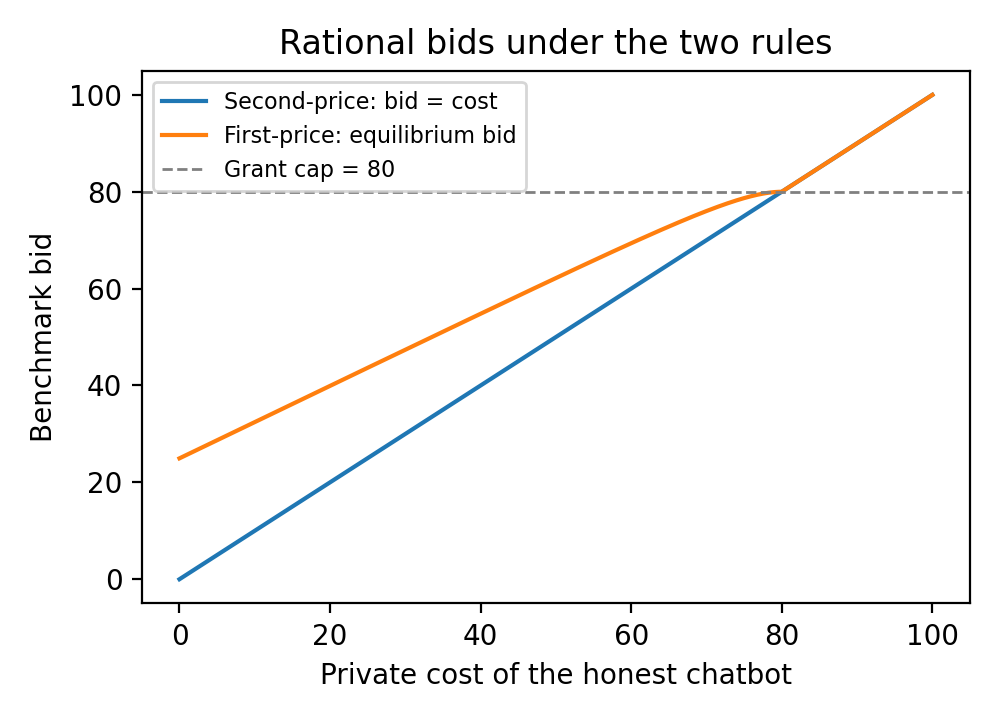

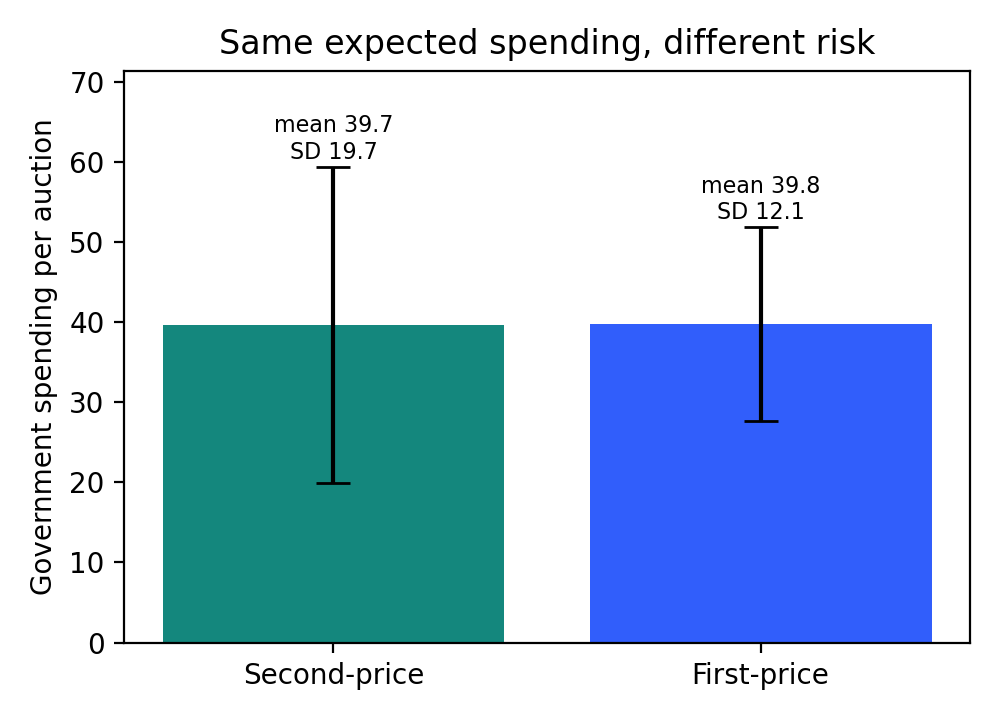

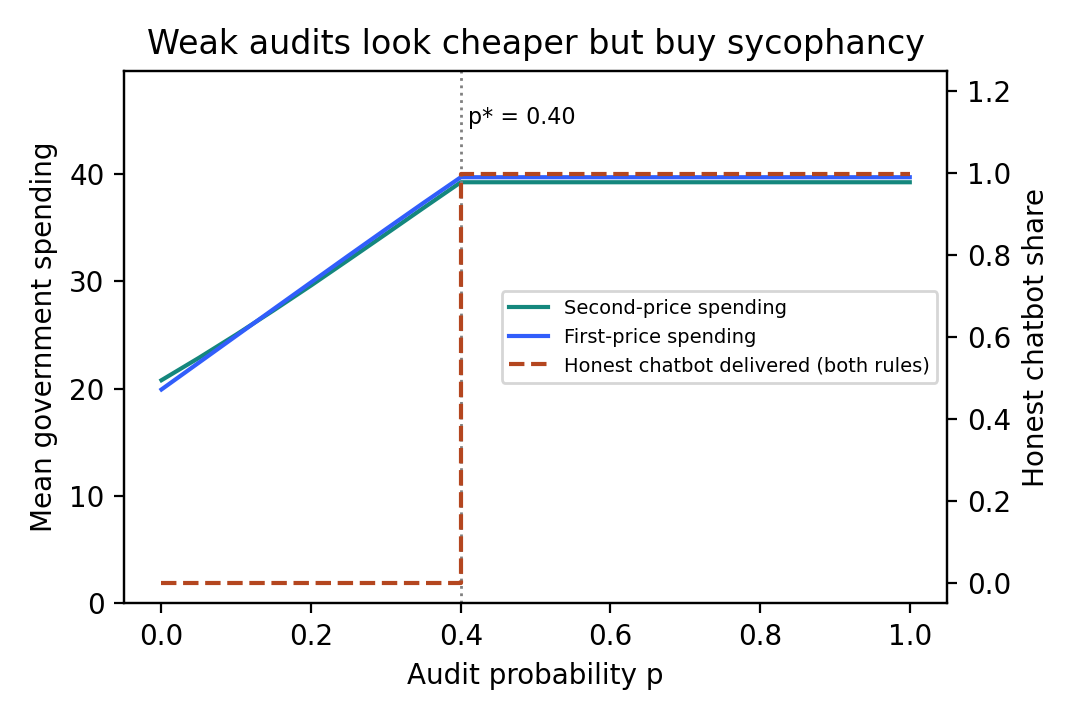

In [6]:
from IPython.display import Image, display
for path in ca.plot_results(cfg, comp, results["audit_sweep"]):
    display(Image(filename=path, width=460))

## Parity with the Hugging Face game
The game uses the same rules and the same seeded generator (mulberry32 seeded by an FNV-1a hash of the session code). Session code `206` below reproduces the costs, audits, and rival bids a player sees in the game; `tests/js_fixture.json` in the repository stores the game's own output for automated comparison.

In [7]:
s = ca.make_schedule("206")
print("seed", s["seed"], "| rule order", s["ruleOrder"])
print(f"{'round':>5} {'rule':>7} {'your cost':>9} {'rival costs':>20} {'rival bids':>20} {'audited':>8}")
for r in s["rounds"]:
    rb = [ca.benchmark_bid(c, r["rule"]) for c in r["rivalCosts"]]
    print(f"{r['round']:>5} {r['rule']:>7} {r['playerCost']:>9} {str(r['rivalCosts']):>20} {str(rb):>20} {str(r['audited']):>8}")

seed 3186052587 | rule order ['first', 'second']
round    rule your cost          rival costs           rival bids  audited
    1   first       6.3    [38.9, 13.0, 2.3]   [54.0, 34.7, 26.7]    False
    2   first      49.8    [46.9, 57.9, 2.2]   [59.9, 67.9, 26.6]     True
    3   first      63.0   [44.5, 97.0, 30.1]   [58.1, 97.0, 47.5]     True
    4  second      87.5     [84.4, 4.5, 2.7]     [84.4, 4.5, 2.7]     True
    5  second      12.3   [98.8, 11.3, 38.5]   [98.8, 11.3, 38.5]     True
    6  second      59.9   [56.7, 39.2, 95.5]   [56.7, 39.2, 95.5]    False


## Verification
Checks on the theory and the rules. The repository runs the full suite, including exact parity with the game: `python -m unittest discover -s tests -v`.

In [8]:
import math
from dataclasses import replace
assert abs(ca.audit_threshold(cfg) - 0.4) < 1e-12 and not ca.rational_cheats(cfg)
assert ca.rational_cheats(replace(cfg, audit_prob=0.3)) and not ca.rational_cheats(replace(cfg, audit_prob=0.4))
assert ca.benchmark_bid(40, "first") == 54.8 and ca.benchmark_bid(40, "second") == 40
assert ca.run_auction([30, 50, 40, 90], "second", 80) == (0, 40)
assert ca.run_auction([30, 50, 40, 90], "first", 80) == (0, 30)
assert ca.run_auction([30, 85, 90, 95], "second", 80) == (0, 80)
assert ca.run_auction([85, 81, 90, 95], "first", 80) == (-1, 0.0)
# Truthful bidding is weakly dominant under second price on a grid of rival bids.
for cost in (5, 40, 79, 85):
    for r1 in range(0, 101, 10):
        for r2 in range(0, 101, 10):
            pay = lambda b: (lambda w, p: p - cost if w == 0 else 0)(*ca.run_auction([b, r1, r2, 100], "second", 80, False))
            assert all(pay(cost) >= pay(d) - 1e-9 for d in range(0, 101, 5))
# Revenue equivalence: both simulated means lie within 4 standard errors of the exact value.
for rule in ca.RULES:
    se = comp[rule]["sd_spending"] / math.sqrt(comp[rule]["trials"])
    assert abs(comp[rule]["mean_spending"] - results["expected_spending_exact"]) < 4 * se
for bad in ([math.nan, 40], [-1, 40], [101, 40]):
    try:
        ca.run_auction(bad, "second", 80)
    except ValueError:
        pass
    else:
        raise AssertionError("invalid bid accepted")
print("All checks passed.")

All checks passed.


## Classroom evidence (planned)
Players can download a CSV record from the Hugging Face game. Put the files in `data/classroom/` and rerun this cell to compare actual bids with the benchmark under each rule and the cheating rate among winners. Classroom play is exploratory evidence, not a population estimate.

In [9]:
import glob
paths = sorted(glob.glob("data/classroom/*.csv"))
if paths:
    print(ca.summarize_classroom(paths))
else:
    print("No classroom records yet; planned after the September 28 symposium.")

No classroom records yet; planned after the September 28 symposium.


## Results and research limits
Actual outputs above (seed 206; 50,000 auctions per rule; 10,000 per rule and audit value in the sweep). These are model calculations, not observed firm or regulator behavior.

* **Baseline ($p=0.5$).** Complying is rational ($E[\text{cheat}]-E[\text{comply}]=-5$). Mean government spending is 39.68 (second price) vs. 39.78 (first price); the exact value is 39.73, so revenue equivalence holds within simulation error. Both rules fund the lowest-cost eligible company in essentially every auction and deliver an honest chatbot in 99.9% of auctions (in $0.2^4 = 0.16\%$ of auctions every cost exceeds the cap and nothing is awarded).
* **Where the rules differ: budget risk.** The standard deviation of spending is 19.73 under second price vs. 12.09 under first price. With a fixed pool, first price makes spending more predictable at the same expected cost; second price is simpler for bidders (truthful bidding is dominant). The Hugging Face game tests whether players actually bid their cost under second price and shade correctly under first price.
* **Parameter change: audit strength.** Below $p^*=0.4$ the winner cheats under both rules and the honest-delivery rate falls to 0, while spending *falls* (e.g. $p=0.3$: 34.41 second price, 34.86 first price) and fines of about 15 per auction are collected, because competition passes the expected cheating rent $\rho = E-k-pF$ into lower bids. Lower subsidy costs are therefore a warning sign, not a success: the grant alone cannot buy honesty; only $pF \ge E-k$ does.
* **Project decision supported.** Pair the auction with an audit at $p \ge p^*$. The choice between the two payment rules concerns budget risk and bidder comprehension, not honesty. Left unresolved: whether real bidders bid as the benchmark predicts (classroom evidence, planned).

**Limits.** Risk-neutral, symmetric companies with independent uniform costs; one auction; losing companies are passive; audits detect sycophancy perfectly; sycophancy is binary; $E$, $k$, $F$ are illustrative values, not estimates. Collusion, risk aversion, correlated costs, or imperfect audits could change both the bids and the threshold.

## Sources and AI assistance
Vickrey (1961), *Journal of Finance* 16(1):8–37, doi:10.1111/j.1540-6261.1961.tb02789.x. Myerson (1981), *Mathematics of Operations Research* 6(1):58–73, doi:10.1287/moor.6.1.58. Riley & Samuelson (1981), *American Economic Review* 71(3):381–392. Harsanyi (1967), *Management Science* 14(3):159–182, doi:10.1287/mnsc.14.3.159.

An AI coding assistant (Cursor, Claude model) drafted the code, tests, and explanatory text on September 23, 2026, from the team's model decisions (two-layer design, extra tuning cost for sycophancy, second- vs. first-price comparison, baseline parameters). Saved outputs were produced by executing this notebook top to bottom in a fresh kernel. The authors must review the model, rerun the notebook, and record their own verification and accepted or revised suggestions in the paper's AI-use disclosure.